# General Models, Specialized Problems: Why Fine-Tuning Matters
### Lab 3: Motivation behind Fine-tunning

---

<img src="figures/lab3-intro.png" width="800">


## What You Will Learn in This Notebook

1. Explore the **PubMedQA** dataset and understand its structure, labels, and biomedical question-answering format.  
   A deeper analysis of the dataset can be found in the supplementary notebook.

2. Design a chat template tailored for the **PubMedQA** task and biomedical reasoning workflows.

3. Probe a **base language model** (llama 3.2-3b instruct) on PubMedQA without fine-tuning to evaluate its zero-shot capabilities.

4. Observe model hallucination in practice — even when the response is incorrect, the model may still generate highly confident and persuasive explanations.

## Prerequisites
- Completion of Tutorial 1 (Hello SLM) and Tutorial 2 (Chat Templates)


---
## Step 1 - PubMed QA at a Glance

**PubMed QA** is a biomedical question answering benchmark built from
peer-reviewed abstracts on PubMed. The task is deliberately narrow and clinically
relevant: given a research question and the corresponding abstract, output a
single verdict — *yes*, *no*, or *maybe*.

### Dataset structure

Each example contains four key fields:

| Field | Description |
|---|---|
| `question` | often the paper title rephrased as a direct question |
| `context_full_text` | One or more paragraphs from the PubMed abstract (background, methods, results) |
| `long_answer` | The abstract's concluding sentence(s) — the human-written summary of the finding |
| `final_decision` | Human-verified label: `yes`, `no`, or `maybe` |

╔════════════════════════════════════════════════════════════════╗
║  EXAMPLE — Expected answer: YES                                 ║
╠════════════════════════════════════════════════════════════════╣
║  QUESTION                                                        ║
║  Is the breast best for children with a family history of      ║
║  atopy?                                                        ║
╠────────────────────────────────────────────────────────────────╣
║  CONTEXT  (abstract excerpt)                                    ║
║  Previous studies reported that breast-feeding protects        ║
║  children against a variety of diseases, but these studies     ║
║  were generally conducted on 'high-risk' or hospitalised       ║
║  children. This paper describes the results of our study on    ║
║  the effects of breast-feeding on rate of illness in normal    ║
║  children with and without a family history of atopy,          ║
║  recruited from a community-based birth cohort.         

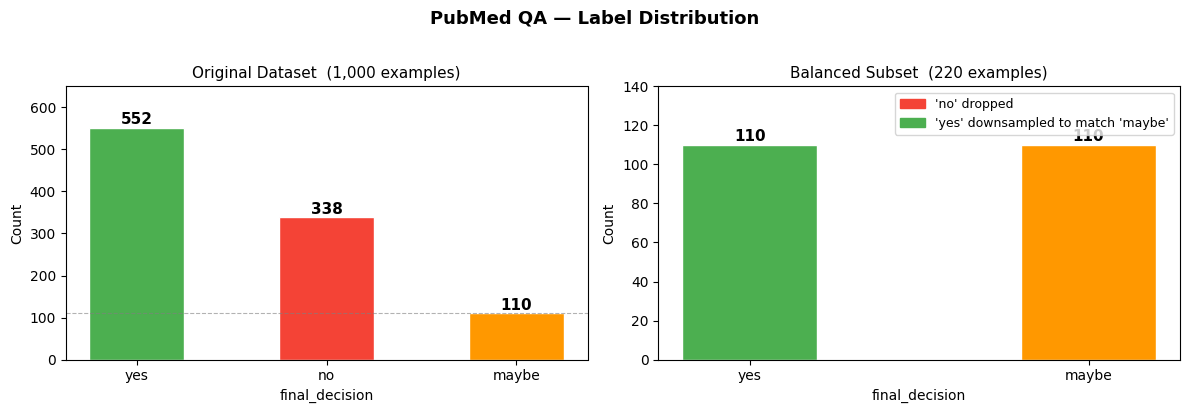

Original — yes: 552, no: 338, maybe: 110
Balanced — yes: 110, maybe: 110
Imbalance ratio (original yes/maybe): 5.02x


In [1]:
from utils import show_examples, plot_label_distribution
from datasets import load_from_disk
show_examples()
plot_label_distribution()


In [2]:
#Dataset is available in the Lab-03 directory
dataset = load_from_disk('dataset_pubmed_qa_yes_maybe')
len(dataset)

220

---
## Environment Check

Confirm that PyTorch sees your GPU before loading a 3 B-parameter model.
A CUDA-capable GPU with at least 8 GB VRAM is recommended.


In [3]:
import os, warnings
warnings.filterwarnings('ignore')

import torch
print('Torch version :', torch.__version__)
print('CUDA available :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU            :', torch.cuda.get_device_name(0))
    print('VRAM           :', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
else:
    print('WARNING: No GPU detected. Training will be very slow on CPU.')


Torch version : 2.10.0a0+b558c986e8.nv25.11
CUDA available : True
GPU            : NVIDIA GB10
VRAM           : 128.5 GB


---
## Step 2 — Install Dependencies

> Skip this cell if you already completed Tutorial 1 or 2 in the same environment.

We need:
- **`unsloth`** — optimised engine for loading quantised SLMs quickly
- **`scikit-learn`** — for stratified train/validation splitting


In [ ]:
%%capture
import os, re
if 'COLAB_' not in ''.join(os.environ.keys()):
    # Local install
    !pip install unsloth trl scikit-learn
else:
    import torch
    v = re.match(r'[0-9]{1,}\.[0-9]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==0.0.27' if v == '2.2' else 'xformers'
    !pip install --no-deps packaging ninja einops flash_attn {xformers} trl tyro datasets scikit-learn
    !pip install unsloth


---
## Step 3 — Load the Base Model and Tokenizer

**Goal:** Load LLaMA 3.2 3B Instruct in 4-bit quantisation — exactly as in Tutorial 2.

> **Important:** We load the *base* model only. We do **not** attach LoRA adapters
> and we do **not** run any training. This is a deliberate choice — we want to measure
> what the model already knows before fine-tuning touches it.

| Setting | Value | Reason |
|---|---|---|
| `max_seq_length` | 1024 | PubMed abstracts are longer than a typical chat turn |
| `load_in_4bit` | `True` | Reduces VRAM from ~6 GB to ~2 GB with negligible quality loss |


In [4]:
from unsloth import FastLanguageModel

MODEL_NAME     = 'unsloth/llama-3.2-3b-instruct'
MAX_SEQ_LENGTH = 1024

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    load_in_4bit   = True,
)
print('Model loaded  :', MODEL_NAME)
print('Max seq length:', MAX_SEQ_LENGTH)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.4: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    NVIDIA GB10. Num GPUs = 1. Max memory: 119.635 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0a0+b558c986e8.nv25.11. CUDA: 12.1. CUDA Toolkit: 13.0. Triton: 3.7.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Model loaded  : unsloth/llama-3.2-3b-instruct
Max seq length: 1024


---
## Step 4 — Format Examples as Chat Messages

**Goal:** Wrap each `(question, context, answer)` triple into a chat-template string,
the same format the model was instruction-tuned on during pre-training.


<img src="figures/data_prepration.png" width="400">



In [5]:
SYSTEM_PROMPT = (
    'You are a biomedical question answering assistant. '
    'You will be given a question and context from a PubMed abstract. '
    'Answer with exactly one word: yes or maybe.'
)

def format_example(example):
    """Convert a raw dataset row into a chat-formatted training string."""
    messages = [
        {'role': 'system',    'content': SYSTEM_PROMPT},
        {'role': 'user',      'content': f"Question: {example['question']}\n\nContext: {example['context_full_text']}"},
        {'role': 'assistant', 'content': example['final_decision']},
    ]
    return {
        'text': tokenizer.apply_chat_template(
            messages,
            tokenize              = False,
            add_generation_prompt = False,
        )
    }

formatted_dataset = dataset.map(format_example, desc='Formatting examples')

print('Formatted example:')
print('-' * 65)
print(formatted_dataset[0]['text'])
print('-' * 65)
print(f'\nTotal formatted examples: {len(formatted_dataset):,}')


Formatted example:
-----------------------------------------------------------------
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 25 Mar 2026

You are a biomedical question answering assistant. You will be given a question and context from a PubMed abstract. Answer with exactly one word: yes or maybe.<|eot_id|><|start_header_id|>user<|end_header_id|>

Question: Do parents recall and understand children's weight status information after BMI screening?

Context: As parents of young children are often unaware their child is overweight, screening provides the opportunity to inform parents and provide the impetus for behaviour change. We aimed to determine if parents could recall and understand the information they received about their overweight child after weight screening. Randomised controlled trial of different methods of feedback. Participants were recruited through primary and secondary care but appointments took place

---
## Step 5 — Create a Stratified Train / Validation Split

**Goal:** Reserve 20 % of examples for evaluation with balanced class proportions.

With only 676 examples a random split could accidentally skew the label distribution.
Stratification guarantees exactly equal `yes` / `maybe` counts in both halves.

| Split | Size | `yes` | `maybe` |
|---|---|---|---|
| Train | 176 (80 %) | 88 | 88 |
| Validation | 44 (20 %) | 22 | 22 |

> **Why create a split in a demo notebook?**
> We evaluate on this same 136-example validation set in the main SFT tutorial,
> so both notebooks report numbers on identical held-out data — a fair comparison.

In [6]:
from sklearn.model_selection import train_test_split
from  collections import Counter
indices = list(range(len(formatted_dataset)))
labels  = formatted_dataset['final_decision']

train_idx, val_idx = train_test_split(
    indices,
    test_size    = 0.2,
    stratify     = labels,
    random_state = 42,
)

train_dataset = formatted_dataset.select(train_idx)
val_dataset   = formatted_dataset.select(val_idx)

print(f'Train : {len(train_dataset):,} examples — {dict(Counter(train_dataset["final_decision"]))}')
print(f'Val   : {len(val_dataset):,}  examples — {dict(Counter(val_dataset["final_decision"]))}')


Train : 176 examples — {'maybe': 88, 'yes': 88}
Val   : 44  examples — {'yes': 22, 'maybe': 22}


---
## Step 5 — Test the Base Model on Medical final Decision Prediction Yes/Maybe (No Fine-Tuning)

**Goal:** Assess the ability of the model to make a definitive decision for biomedical questions using the provided context without any fine-tuning, and evaluate its prediction accuracy.

This is the key experiment. We deliberately skip LoRA and training entirely.
The model evaluated below is the raw pre-trained checkpoint — unchanged from Step 2.

### What to watch for

| Question | Why it matters |
|---|---|
| Does the model follow the one-word instruction? | Format compliance is learned, not guaranteed |
| Does accuracy beat the 50 % random baseline? | A balanced dataset makes 50 % the floor for a trivial classifier |



<img src="figures/final_decision_.png" width="800">

### Part A — Inspect Raw Predictions

Before measuring aggregate accuracy, we look at what the model *actually generates*.
We sample 6 examples (3 per class) and print the raw output string alongside the
expected label.

This reveals the first failure mode immediately: the model often ignores the
one-word instruction and generates multi-sentence explanations.

In [9]:
FastLanguageModel.for_inference(model)
max_new_tokens = 100
SYSTEM_PROMPT = (
    'You are a biomedical question answering assistant. '
    'You will be given a question and context from a PubMed abstract. '
    'Answer with exactly one word: yes or maybe.'
)
idx = 24
question = val_dataset[idx]['question']
context = val_dataset[idx]['context_full_text']
final_decision =  val_dataset[idx]['final_decision']


messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': f'Question: {question}\n\nContext: {context}'},
    ]
prompt  = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True,
    )

inputs  = tokenizer(prompt, return_tensors='pt').to(model.device)
outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
new_tok = outputs[0][inputs['input_ids'].shape[1]:]
        
raw     = tokenizer.decode(new_tok, skip_special_tokens=True).strip()   
Prediction  = raw.split()[0].lower().strip('.,!?;:') if raw else ''   # first word, punctuation stripped

print('Final Decision: ', final_decision, '\n')
print('Predicted Final Decision: ', Prediction, '\n')


Final Decision:  maybe 

Predicted Final Decision:  yes 



In [10]:
FastLanguageModel.for_inference(model)

def predict(question, context, max_new_tokens=3200):
    """Return (raw_output_string, parsed_first_word) for one example."""
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': f'Question: {question}\n\nContext: {context}'},
    ]
    prompt  = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True,
    ) # create a single format string (prompt), given list of {role,content}
    #print("########  prompt ######## ", '\n', prompt)
    inputs  = tokenizer(prompt, return_tensors='pt').to(model.device)
    outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    new_tok = outputs[0][inputs['input_ids'].shape[1]:]
    
    
    raw     = tokenizer.decode(new_tok, skip_special_tokens=True).strip()
    
   
    parsed  = raw.split()[0].lower().strip('.,!?;:') if raw else ''   # first word, punctuation stripped
    return raw, parsed

In [11]:
# ── Sample 6 examples (3 yes, 3 maybe) and show raw output ──────────────────────
print("BASE MODEL — RAW OUTPUTS  (no fine-tuning)")
print("=" * 65)
shown = {'yes': 0, 'maybe': 0}
for ex in val_dataset:
    label = ex['final_decision']
    
    if shown[label] >= 3:
        continue
    raw, parsed = predict(ex['question'], ex['context_full_text'])
    icon = '✓' if parsed == label else '✗'
    print(f"\n  Expected  : {label.lower()}")
    print(f"  Parsed 1st word: {parsed!r}  {icon}")
    shown[label] += 1
    if all(v >= 5 for v in shown.values()):
        break

BASE MODEL — RAW OUTPUTS  (no fine-tuning)

  Expected  : yes
  Parsed 1st word: 'yes'  ✓

  Expected  : yes
  Parsed 1st word: 'yes'  ✓

  Expected  : yes
  Parsed 1st word: 'yes'  ✓

  Expected  : maybe
  Parsed 1st word: 'yes'  ✗

  Expected  : maybe
  Parsed 1st word: 'yes'  ✗

  Expected  : maybe
  Parsed 1st word: 'maybe'  ✓


### Part B — Full Accuracy on 136 Validation Examples

Now we run the same inference loop over the complete held-out set and report accuracy.


In [12]:
correct = 0
results = []

for ex in val_dataset:
    raw, pred = predict(ex['question'], ex['context_full_text'])
    true      = ex['final_decision']
    match     = pred == true
    correct  += int(match)
    results.append({'true': true, 'pred': pred, 'raw': raw, 'match': match})

accuracy = correct / len(val_dataset)
print(f"Validation accuracy : {correct}/{len(val_dataset)} = {accuracy:.1%}")
print(f"Random baseline     : 50.0%  (always predict 'yes' on balanced data)")
print(f"Delta vs baseline   : {(accuracy - 0.5)*100:+.1f} pp")


Validation accuracy : 23/44 = 52.3%
Random baseline     : 50.0%  (always predict 'yes' on balanced data)
Delta vs baseline   : +2.3 pp


### Part C — Per-Class Accuracy

A single aggregate number can hide asymmetric failures.
Breaking results down by true label shows whether the model favours one class —
which on a balanced dataset is a clear sign of systematic bias.


In [13]:
from collections import defaultdict

per_class = defaultdict(lambda: {'correct': 0, 'total': 0})
for r in results:
    per_class[r['true']]['total']   += 1
    per_class[r['true']]['correct'] += int(r['match'])

print(f"{'Label':<8} {'Correct':>8} {'Total':>7} {'Accuracy':>10}")
print('-' * 38)
for label in ['yes', 'maybe']:
    c = per_class[label]['correct']
    t = per_class[label]['total']
    print(f"{label:<8} {c:>8} {t:>7} {c/t:>10.1%}")
print('-' * 38)
print(f"{'Overall':<8} {correct:>8} {len(val_dataset):>7} {accuracy:>10.1%}")


Label     Correct   Total   Accuracy
--------------------------------------
yes            20      22      90.9%
maybe           3      22      13.6%
--------------------------------------
Overall        23      44      52.3%


---
## Why Does the Base Model Fail?


### Failure Mode 1 — Domain Uncertainty

The asymmetry in per-class accuracy (typically one class scores ~0 %) reveals that
the base model is not guessing randomly — it has a strong systematic bias toward one
label, almost certainly driven by the first-word statistics of its training data
rather than actual reading of the abstract.

---
## Step 6 — Test the Base Model on Medical Reasoning (No Fine-Tuning)

**Goal:** Assess the ability of the model to generate coherent biomedical reasoning from the provided context without any fine-tuning, and evaluate whether the reasoning aligns with the correct medical conclusion.


<img src="figures/Medical_reasoning_prediction.png" width="800">

In [14]:
FastLanguageModel.for_inference(model)
max_new_tokens = 200
SYSTEM_PROMPT = (
    'You are a biomedical question answering assistant. '
    'You will be given a question and context from a PubMed abstract. '
    'Answer with  comperhensive medical reasoning in one sentence.'
)
idx= 24
question = val_dataset[idx]['question']
context = val_dataset[idx]['context_full_text']
long_answer =  val_dataset[idx]['long_answer']
final_decision =  val_dataset[idx]['final_decision']


messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': f'Question: {question}\n\nContext: {context}'},
    ]
prompt  = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True,
    ) # create a single format string (prompt), given list of {role,content}
    #print("########  prompt ######## ", '\n', prompt)
inputs  = tokenizer(prompt, return_tensors='pt').to(model.device)
outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
new_tok = outputs[0][inputs['input_ids'].shape[1]:]
        
medical_reasoning     = tokenizer.decode(new_tok, skip_special_tokens=True).strip()   
predicted_decision = 'yes' # we know it from previous experiment
width = 80
sep = "-" * width

print(f"\n{'=' * width}")
print("QUESTION")
print(sep)
print(question)

print(f"\n{'=' * width}")
print("CONTEXT")
print(sep)
print(context)

print(f"\n{'=' * width}")
print("PREDICTED ANSWER  (model)")
print(sep)
# Extract only the answer portion
if "**Answer:**" in medical_reasoning:
    medical_reasoning = medical_reasoning.split("**Answer:**")[-1].strip()
elif "Answer:" in medical_reasoning:
    medical_reasoning = medical_reasoning.split("Answer:")[-1].strip()
print(medical_reasoning)

print(f"\n{'=' * width}")
print("GROUND TRUTH ANSWER")
print(sep)
print(long_answer)

print(f"\n{'=' * width}")
print("FINAL DECISION")
print(sep)
print(f"  Predicted    : {predicted_decision}")
print(f"  Ground truth : {final_decision}")
match = "✓ MATCH" if predicted_decision.lower() == final_decision.lower() else "✗ MISMATCH"
print(f"  Result       : {match}")
print('=' * width)



QUESTION
--------------------------------------------------------------------------------
Are normally sighted, visually impaired, and blind pedestrians accurate and reliable at making street crossing decisions?

CONTEXT
--------------------------------------------------------------------------------
The purpose of this study is to measure the accuracy and reliability of normally sighted, visually impaired, and blind pedestrians at making street crossing decisions using visual and/or auditory information. Using a 5-point rating scale, safety ratings for vehicular gaps of different durations were measured along a two-lane street of one-way traffic without a traffic signal. Safety ratings were collected from 12 normally sighted, 10 visually impaired, and 10 blind subjects for eight different gap times under three sensory conditions: (1) visual plus auditory information, (2) visual information only, and (3) auditory information only. Accuracy and reliability in street crossing decision-m


## Why Does the Base Model Produce Misleading Medical Reasoning?

### Failure Mode 2 — Persuasive but Incorrect Reasoning

One of the most important observations is that the model often generates
highly fluent and scientifically convincing explanations even when the final
medical decision is incorrect.

The reasoning appears coherent on the surface:
- it uses biomedical terminology correctly,
- references findings from the abstract,
- and follows a logical narrative structure.

However, the generated explanation may still misinterpret the actual conclusion
of the study or selectively emphasize evidence that supports the model’s predicted label.

### The key scientific insight

This reveals an important limitation of base language models in specialized domains:

> Linguistic fluency should not be confused with factual or clinical correctness.

The model is capable of generating persuasive medical narratives without truly
grounding its reasoning in the underlying scientific evidence.


---

## Conclusion — What Supervised Fine-Tuning Fixes

| Problem observed in the base model | How Supervised Fine-Tuning (SFT) addresses it |
|---|---|
| The model struggles with biomedical decision-making | Fine-tuning exposes the model to biomedical terminology, reasoning patterns, and domain-specific evidence interpretation |
| The model exhibits strong class bias and unreliable predictions | SFT calibrates the model toward the true task distribution instead of relying on superficial statistical priors |
```



## Assignment

Can you modify the model behavior such that it generates:

- A final decision (`Yes` or `Maybe`) **AND** a detailed medical reasoning that justifies the prediction

### Hint

Think about how changing the **System Prompt** may influence:
- the response format,
- the level of explanation,
- and the reasoning style of the model.